# One-dimensional Regression with NNs 

We want to approximate the following unkown (scalar real-valued) function $f\colon D \subset \mathbb{R} \rightarrow \mathbb{R}$ with a _neural network model_ given input-output $K$ pairs $(x^{(k)}, y^{(k)})_{k=1}^K$ of the data. 

Import dependencies

In [1]:
import sys; sys.path.append('../src/playground_jax')
from time import time

import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import numpy as jnp
from jaxtyping import Array
from sklearn.metrics import r2_score

jax.config.update("jax_enable_x64", True)

Define *target function*. For instance, $x \mapsto f(x) = \sqrt{|x|}$

In [2]:
def f_fn(x: Array):
    return jnp.sqrt(jnp.abs(x))
    #return jnp.pow(x, 2)
    #return jnp.exp(x)
    #return jnp.sin(jnp.pi *x)

Get training data by using the discretized 1-dimensional grid as the input

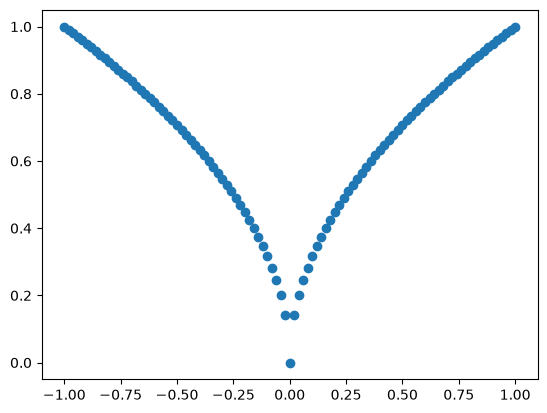

In [3]:
N = 101
x_min, x_max = -1, 1
x_train = jnp.linspace(x_min, x_max, N).reshape(-1, 1)
y_train = f_fn(x_train)
plt.scatter(x_train, y_train);

Build a _multilayer perceptron (MLP)_ feedforward neural network
1. Define method to initialize the model parameters

In [4]:
def init_mlp_params(layer_widths: list) -> list[dict]:
    '''
    Initializes parameters for an MLP and returns them
    wrapped in a list.
    '''
    params = []
    for n_in, n_out in zip(layer_widths[:-1], layer_widths[1:]):
        # weights and bias for each layer
        params.append(
            dict(
                weights=np.random.normal(size=(n_in, n_out)) * np.sqrt(2 / n_in),
                biases=np.ones(shape=(n_out,))
            )
        )
    return params

2. Set neural network architecture and initialize parameters

In [5]:
# set input, output and hidden dimensions
d_in, d_hiddens, d_out = 1, [32, 16, 8], 1
params = init_mlp_params([d_in] + d_hiddens + [d_out])

# check shapes
jax.tree_util.tree_map(lambda x: x.shape, params)

[{'biases': (32,), 'weights': (1, 32)},
 {'biases': (16,), 'weights': (32, 16)},
 {'biases': (8,), 'weights': (16, 8)},
 {'biases': (1,), 'weights': (8, 1)}]

3. Define forward method for the model

In [7]:
@jax.jit
def forward(params: list, x: Array, activation=jax.nn.tanh, 
            final_activation=lambda x: x) -> Array:
    '''
    Performs a forward pass
    '''
    *hidden, last = params
    for layer in hidden:
        x = activation(x @ layer['weights'] + layer['biases'])
    return final_activation(x @ last['weights'] + last['biases'])

In [8]:
y_init = forward(params, x_train)

Define MSE loss

In [11]:
@jax.jit
def mse(params: list, x: Array, y: Array) -> Array:
    '''
    Computes mean square error (mse) between the target function and the model
    '''
    return (forward(params, x) - y)**2

@jax.jit
def loss_fn(params: list, x: Array, y: Array) -> Array:
    '''
    Implements Mean Square Loss
    '''
    return jnp.mean(mse(params, x, y))

Define update function method

In [12]:
@jax.jit
def train_step(params: list, x: Array, y: Array, lr: float = 1e-3) -> list:
    '''
    Evaluates loss, computes gradients and updates parameters using SGD.
    '''
    # evaluate loss and compute gradients
    loss_value, grads = jax.value_and_grad(loss_fn)(params, x, y)

    # update params (`grads` is a pytree with the same structure as `params`)
    params = jax.tree_util.tree_map(
        lambda p, g: p - lr * g, params, grads
    )
    return params, loss_value

Train

In [13]:
lr = 1e-2
n_iter = int(1e4)
log_period_iter = int(1e3)
for i in range(n_iter):
    t0 = time()
    params, loss_value = train_step(params, x_train, y_train, lr)
    t1 = time()
    if i % log_period_iter  == 0: 
        print('it: {:d}, loss: {:.3e}, time: {:.4f}s'.format(i, loss_value, t1-t0))

it: 0, loss: 1.062e-01, time: 0.1498s
it: 1000, loss: 3.333e-03, time: 0.0000s
it: 2000, loss: 2.624e-03, time: 0.0000s
it: 3000, loss: 2.240e-03, time: 0.0001s
it: 4000, loss: 2.001e-03, time: 0.0000s
it: 5000, loss: 1.834e-03, time: 0.0001s
it: 6000, loss: 1.709e-03, time: 0.0001s
it: 7000, loss: 1.611e-03, time: 0.0000s
it: 8000, loss: 1.530e-03, time: 0.0001s
it: 9000, loss: 1.462e-03, time: 0.0000s


Evaluate results

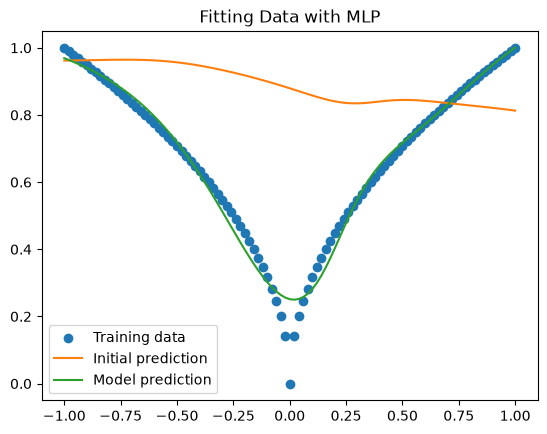

In [14]:
y_pred = forward(params, x_train)
fig, ax = plt.subplots()
ax.set_title('Fitting Data with MLP');
ax.scatter(x_train, y_train, c='tab:blue', label='Training data')
ax.plot(x_train, y_init, c='tab:orange', label='Initial prediction')
ax.plot(x_train, y_pred, c='tab:green', label='Model prediction')
ax.legend();

Compute _r2 score_

In [15]:
r2 = round(float(r2_score(y_train, y_pred)), 3)
print("R^2 Score:", r2)

R^2 Score: 0.975
